In [1]:
import os
import re

import numpy as np
import torch
import pandas as pd
import matplotlib
import seaborn as sns
import pickle
from tqdm.notebook import tqdm
from scipy.interpolate import interp1d
from functionsgpu_old import *
from val_test import val_test
from tslearn import metrics
from joblib import Parallel, delayed

import warnings
warnings.filterwarnings("ignore")

device = torch.device('cuda:1' if torch.cuda.is_available() else 'cpu')
print(device)
dtype = torch.float32

if device.type == "cuda":
    idx = device.index if device.index is not None else torch.cuda.current_device()
    print(torch.cuda.get_device_name(idx))
    
tslen = 200

cuda:1
NVIDIA RTX A5000


## Data Loading For DTW

In [2]:
def loading():
    with open('unaligned_betas.pkl','rb') as f:
        betas = pickle.load(f)
    with open('euclidean_mean.pkl','rb') as f:
        mu = pickle.load(f)
    return betas, mu


betas_all_arr, mu_all_t = loading()
print(betas_all_arr.shape)

(155, 32, 3, 200)


## DTW Distance Matrix Computation

In [3]:
N, K, M, T = betas_all_arr.shape
beta_reshaped = betas_all_arr.transpose(0, 3, 1, 2).reshape(N, T, K * M)
print(beta_reshaped.shape)
X = beta_reshaped

N = X.shape[0]
dist_dtw = np.zeros((N, N))
    
for i in tqdm(range(X.shape[0])):
    for j in range(X.shape[0]):
        beta1 = X[i, :, :]
        beta2 = X[j, :, :]

        dist_dtw[i, j] = metrics.dtw(beta1, beta2)

(155, 200, 96)


  0%|          | 0/155 [00:00<?, ?it/s]

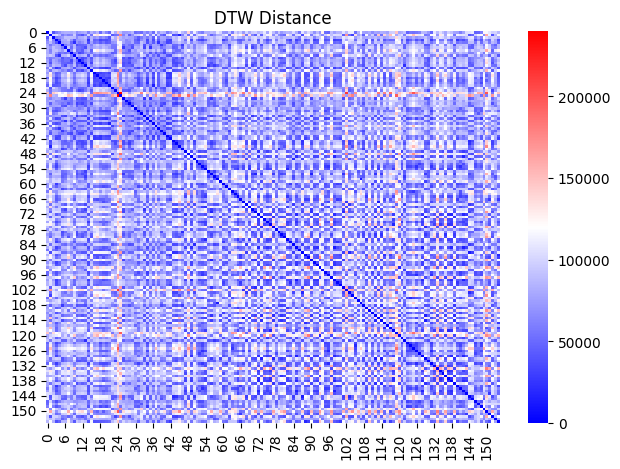

In [4]:
sns.heatmap(dist_dtw, cmap='bwr')
plt.title("DTW Distance")
plt.savefig('result_figures/dtw_dist.png', dpi=300, bbox_inches='tight')
plt.savefig('result_figures/dtw_dist.eps', bbox_inches='tight')
plt.tight_layout()
plt.show()

## POMA and Participant ID Load

In [5]:
X = dist_dtw

folder_path = "/mnt/sdb/arafat/stroke_riemann/csv_r"
files = [file for file in os.listdir(folder_path)]
files = sorted(files, key=lambda x: int(x.split('_')[0][2:]))
scores_w_csv = [file.split('_')[1] for file in files]
scores = [file.split('.')[0] for file in scores_w_csv]

y = np.array(scores).astype(int)

# Participant ID for each row of X (same order as files from csv_r)
participant_ids = [re.search(r'ID(\d+)_', f).group(1) for f in files]
step = 10  # same as tcn_tangents: leave-10-participants-out per fold

print(X.shape, y.shape)
print("all_participants (first 15):", participant_ids[:15])

(155, 155) (155,)
all_participants (first 15): ['1', '2', '3', '4', '5', '6', '7', '8', '10', '11', '13', '14', '15', '17', '18']


## k-NN Regression (DTW)

In [6]:
from sklearn.neighbors import KNeighborsRegressor
from sklearn.metrics import mean_absolute_error, mean_squared_error, r2_score
from scipy import stats
from tqdm.notebook import tqdm
from print_results import print_results

# Same CV: 5 validation + 5 test (disjoint) per fold, two rounds so every subject is validated and tested once.
n = len(y)
n_folds = 30

models = {'KNN': KNeighborsRegressor(metric='precomputed')}

all_results_validation = {name: {'targets': [], 'preds': []} for name in models.keys()}
all_results_test = {name: {'targets': [], 'preds': [], 'subjects': []} for name in models.keys()}
participant_ids = np.asarray(participant_ids)

for name, model in tqdm(models.items(), desc='Models'):
    for k in tqdm(range(n_folds), total=n_folds, desc=name, leave=False):
        validation_pids_list, test_pids_list = val_test(participant_ids, k)
        validation_pids = set(validation_pids_list)
        test_pids = set(test_pids_list)
        train_pids = set(participant_ids) - validation_pids - test_pids

        train_idx = np.array([j for j in range(n) if participant_ids[j] in train_pids])
        validation_idx = np.array([j for j in range(n) if participant_ids[j] in validation_pids])
        test_idx = np.array([j for j in range(n) if participant_ids[j] in test_pids])
        if len(train_idx) == 0 or len(validation_idx) == 0 or len(test_idx) == 0:
            continue

        X_train = X[np.ix_(train_idx, train_idx)]
        X_validation = X[np.ix_(validation_idx, train_idx)]
        X_test = X[np.ix_(test_idx, train_idx)]

        y_train = y[train_idx]
        m = type(model)(**model.get_params())
        m.fit(X_train, y_train)

        validation_preds = m.predict(X_validation)
        test_preds = m.predict(X_test)
        all_results_validation[name]['targets'].extend(y[validation_idx].tolist())
        all_results_validation[name]['preds'].extend(validation_preds.tolist())
        all_results_test[name]['targets'].extend(y[test_idx].tolist())
        all_results_test[name]['preds'].extend(test_preds.tolist())
        all_results_test[name]['subjects'].extend(participant_ids[test_idx].tolist())

        mae_val = mean_absolute_error(y[validation_idx], validation_preds)
        rmse_val = np.sqrt(mean_squared_error(y[validation_idx], validation_preds))
        r2_val = r2_score(y[validation_idx], validation_preds)
        # print(f"Fold {k + 1:02d} | {name} | Validation: MAE={mae_val:.3f}, RMSE={rmse_val:.3f}, R2={r2_val:.3f}")

test_results_df = print_results(all_results_validation, all_results_test, models)
test_results_df

Models:   0%|          | 0/1 [00:00<?, ?it/s]

KNN:   0%|          | 0/30 [00:00<?, ?it/s]


=== Validation Performance (across all folds) ===
          MAE      RMSE        R2  Pearson r     Pearson p
KNN  2.130323  4.076716  0.455791   0.682565  1.364565e-22

=== Test Performance (across all folds) ===


,MAE,RMSE,R2,Pearson r,Pearson p
KNN,2.130323,4.076716,0.455791,0.682565,1.364565e-22


In [7]:
from ci import *
ci_results = {}

name = "KNN"

ci_results[name] = subject_bootstrap_ci(
    all_results_test[name]['targets'],
    all_results_test[name]['preds'],
    all_results_test[name]['subjects'])

pd.DataFrame(ci_results['KNN'])

,MAE,RMSE,R2,Pearson r
mean,2.130323,4.076716,0.455791,0.682565
ci,"[1.709, 2.531]","[3.408, 4.601]","[0.335, 0.566]","[0.593, 0.774]"


## Lesion Left Classification (DTW)

In [11]:
# Create y_lesion from LesionLeft, aligned to same participant_ids order as X
demo_df = pd.read_csv('demo_data.csv')
id_to_lesion = dict(zip(demo_df['s'].astype(int), demo_df['LesionLeft']))
y_lesion = np.array([id_to_lesion[int(pid)] for pid in participant_ids])

print("LesionLeft class distribution:", np.unique(y_lesion, return_counts=True))
print("X.shape:", X.shape, "y_lesion.shape:", y_lesion.shape)

LesionLeft class distribution: (array([0, 1, 2]), array([ 30,  14, 111]))
X.shape: (155, 155) y_lesion.shape: (155,)


In [14]:
from sklearn.neighbors import KNeighborsClassifier
from sklearn.metrics import accuracy_score, f1_score, precision_score, recall_score

# Same CV: 5 validation + 5 test (disjoint) per fold, two rounds so every subject is validated and tested once.
n_cls = len(y_lesion)
n_folds = 30

models_clf = {'KNN': KNeighborsClassifier(metric='precomputed')}

all_val_clf = {name: {'targets': [], 'preds': []} for name in models_clf.keys()}
all_test_clf = {name: {'targets': [], 'preds': [], 'subjects': []} for name in models_clf.keys()}
participant_ids = np.asarray(participant_ids)

for name, model in tqdm(models_clf.items(), desc='Models'):
    for k in tqdm(range(n_folds), total=n_folds, desc=name, leave=False):
        validation_pids_list, test_pids_list = val_test(participant_ids, k)
        validation_pids = set(validation_pids_list)
        test_pids = set(test_pids_list)
        train_pids = set(participant_ids) - validation_pids - test_pids

        train_idx = np.array([j for j in range(n_cls) if participant_ids[j] in train_pids])
        validation_idx = np.array([j for j in range(n_cls) if participant_ids[j] in validation_pids])
        test_idx = np.array([j for j in range(n_cls) if participant_ids[j] in test_pids])
        if len(train_idx) == 0 or len(validation_idx) == 0 or len(test_idx) == 0:
            continue

        X_train = X[np.ix_(train_idx, train_idx)]
        X_validation = X[np.ix_(validation_idx, train_idx)]
        X_test = X[np.ix_(test_idx, train_idx)]

        y_train = y_lesion[train_idx]
        m = type(model)(**model.get_params())
        m.fit(X_train, y_train)
        validation_preds = m.predict(X_validation)
        test_preds = m.predict(X_test)
        all_val_clf[name]['targets'].extend(y_lesion[validation_idx].tolist())
        all_val_clf[name]['preds'].extend(validation_preds.tolist())
        all_test_clf[name]['targets'].extend(y_lesion[test_idx].tolist())
        all_test_clf[name]['preds'].extend(test_preds.tolist())
        all_test_clf[name]['subjects'].extend(participant_ids[test_idx].tolist())

        acc_val = accuracy_score(y_lesion[validation_idx], validation_preds)
        f1_val = f1_score(y_lesion[validation_idx], validation_preds, average='weighted')
        # print(f"Fold {k + 1:02d} | {name} | Validation: Accuracy={acc_val:.3f}, F1={f1_val:.3f}")

# print("\n=== LesionLeft Classification — Validation Performance (across all folds) ===")
results_val_clf = {}
for name in models_clf.keys():
    t = np.array(all_val_clf[name]['targets'])
    p = np.array(all_val_clf[name]['preds'])
    if t.size == 0:
        continue
    results_val_clf[name] = {
        'Accuracy': accuracy_score(t, p),
        'F1 (weighted)': f1_score(t, p, average='weighted'),
        'F1 (macro)': f1_score(t, p, average='macro'),
        'Precision (weighted)': precision_score(t, p, average='weighted', zero_division=0),
        'Precision (macro)': precision_score(t, p, average='macro'),
        'Recall (weighted)': recall_score(t, p, average='weighted', zero_division=0),
        'Recall (macro)': recall_score(t, p, average='macro'),
    }
# print(pd.DataFrame(results_val_clf).T)

print("\n=== LesionLeft Classification — Test Performance (across all folds) ===")
results_clf = {}
predictions_clf = {}
for name in models_clf.keys():
    all_targets = np.array(all_test_clf[name]['targets'])
    all_preds = np.array(all_test_clf[name]['preds'])
    if all_targets.size == 0:
        continue
    predictions_clf[name] = {'y_true': all_targets, 'y_pred': all_preds}
    results_clf[name] = {
        'Accuracy': accuracy_score(all_targets, all_preds),
        'F1 (weighted)': f1_score(all_targets, all_preds, average='weighted'),
        'F1 (macro)': f1_score(all_targets, all_preds, average='macro'),
        'Precision (weighted)': precision_score(all_targets, all_preds, average='weighted', zero_division=0),
        'Precision (macro)': precision_score(all_targets, all_preds, average='macro'),
        'Recall (weighted)': recall_score(all_targets, all_preds, average='weighted', zero_division=0),
        'Recall (macro)': recall_score(all_targets, all_preds, average='macro'),
    }
results_clf_df = pd.DataFrame(results_clf).T
results_clf_df

Models:   0%|          | 0/1 [00:00<?, ?it/s]

KNN:   0%|          | 0/30 [00:00<?, ?it/s]


=== LesionLeft Classification — Test Performance (across all folds) ===


,Accuracy,F1 (weighted),F1 (macro),Precision (weighted),Precision (macro),Recall (weighted),Recall (macro)
KNN,0.825806,0.806432,0.597588,0.797637,0.6458,0.825806,0.576534


In [15]:
from ci_class import subject_bootstrap_ci_class

ci_results = {}

name = "KNN"

ci_results[name] = subject_bootstrap_ci_class(
    all_test_clf[name]['targets'],
    all_test_clf[name]['preds'],
    all_test_clf[name]['subjects'])

pd.DataFrame(ci_results['KNN'])

,Accuracy,F1 (weighted),F1 (macro),Precision (weighted),Precision (macro),Recall (weighted),Recall (macro)
mean,0.825806,0.806432,0.597588,0.797637,0.6458,0.825806,0.576534
ci,"[0.781, 0.872]","[0.755, 0.86]","[0.502, 0.679]","[0.742, 0.863]","[0.505, 0.784]","[0.781, 0.872]","[0.501, 0.651]"


## Raz Align Distance Matrix Computation

In [26]:
def raz_align(template_beta, beta2):
    # Move tensors to same device as OPA_gpu (cuda:1) to avoid device mismatch
    a = torch.from_numpy(beta2).to(device)
    b = torch.from_numpy(template_beta).to(device)
    aligned = OPA_gpu(a, b)
    return aligned.cpu().numpy()

In [46]:
N = betas_all_arr.shape[0]
raz_dist_mat = np.zeros((N, N))

for trial in tqdm(range(20)):
    ref_id = np.random.choice(range(45,154))
    ref = betas_all_arr[ref_id]
    
    for i in tqdm(range(len(betas_all_arr))):
        for j in range(len(betas_all_arr)):
            beta1 = raz_align(ref, betas_all_arr[i])
            beta2 = raz_align(ref, betas_all_arr[j])
            raz_dist_mat[i, j] += np.linalg.norm(beta1-beta2)/20

  0%|          | 0/20 [00:00<?, ?it/s]

  0%|          | 0/155 [00:00<?, ?it/s]

  0%|          | 0/155 [00:00<?, ?it/s]

  0%|          | 0/155 [00:00<?, ?it/s]

  0%|          | 0/155 [00:00<?, ?it/s]

...

  0%|          | 0/155 [00:00<?, ?it/s]

  0%|          | 0/155 [00:00<?, ?it/s]

  0%|          | 0/155 [00:00<?, ?it/s]

  0%|          | 0/155 [00:00<?, ?it/s]

  0%|          | 0/155 [00:00<?, ?it/s]

In [5]:
raz_dist_mat = np.load('raz_dist_mat.pkl',allow_pickle=True)

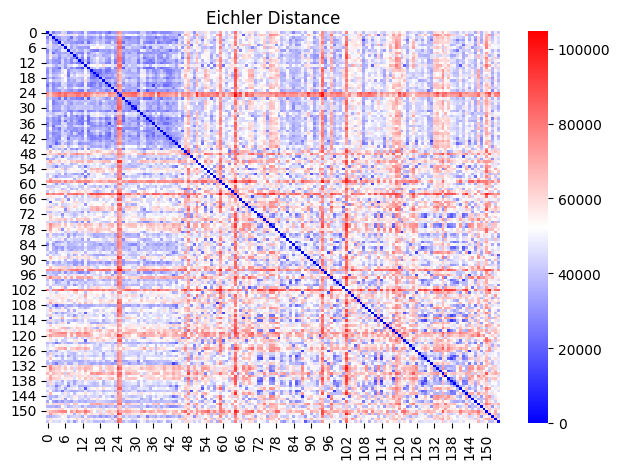

In [6]:
sns.heatmap(raz_dist_mat, cmap='bwr')
plt.title("Eichler Distance")
plt.savefig('result_figures/raz_dist.png', dpi=300, bbox_inches='tight')
plt.savefig('result_figures/raz_dist.eps', bbox_inches='tight')
plt.tight_layout()
plt.show()

In [48]:
with open('raz_dist_mat.pkl','wb') as f:
    pickle.dump(raz_dist_mat, f)

## POMA and Participant ID Load

In [28]:
X = raz_dist_mat

folder_path = "/mnt/sdb/arafat/stroke_riemann/csv_r"
files = [file for file in os.listdir(folder_path)]
files = sorted(files, key=lambda x: int(x.split('_')[0][2:]))
scores_w_csv = [file.split('_')[1] for file in files]
scores = [file.split('.')[0] for file in scores_w_csv]

y = np.array(scores).astype(int)

# Participant ID for each row of X (same order as files from csv_r)
participant_ids = [re.search(r'ID(\d+)_', f).group(1) for f in files]
step = 10  # same as tcn_tangents: leave-10-participants-out per fold

print(X.shape, y.shape)
print("all_participants (first 15):", participant_ids[:15])

(155, 155) (155,)
all_participants (first 15): ['1', '2', '3', '4', '5', '6', '7', '8', '10', '11', '13', '14', '15', '17', '18']


## k-NN Regression (Raz)

In [50]:
from sklearn.neighbors import KNeighborsRegressor
from sklearn.metrics import mean_absolute_error, mean_squared_error, r2_score
from scipy import stats
from tqdm.notebook import tqdm
from print_results import print_results

# Same CV: 5 validation + 5 test (disjoint) per fold, two rounds so every subject is validated and tested once.
n = len(y)
n_folds = 30

models = {'KNN': KNeighborsRegressor(metric='precomputed')}

all_results_validation = {name: {'targets': [], 'preds': []} for name in models.keys()}
all_results_test = {name: {'targets': [], 'preds': [], 'subjects': []} for name in models.keys()}
participant_ids = np.asarray(participant_ids)

for name, model in tqdm(models.items(), desc='Models'):
    for k in tqdm(range(n_folds), total=n_folds, desc=name, leave=False):
        validation_pids_list, test_pids_list = val_test(participant_ids, k)
        validation_pids = set(validation_pids_list)
        test_pids = set(test_pids_list)
        train_pids = set(participant_ids) - validation_pids - test_pids

        train_idx = np.array([j for j in range(n) if participant_ids[j] in train_pids])
        validation_idx = np.array([j for j in range(n) if participant_ids[j] in validation_pids])
        test_idx = np.array([j for j in range(n) if participant_ids[j] in test_pids])
        if len(train_idx) == 0 or len(validation_idx) == 0 or len(test_idx) == 0:
            continue

        X_train = X[np.ix_(train_idx, train_idx)]
        X_validation = X[np.ix_(validation_idx, train_idx)]
        X_test = X[np.ix_(test_idx, train_idx)]

        y_train = y[train_idx]
        m = type(model)(**model.get_params())
        m.fit(X_train, y_train)

        validation_preds = m.predict(X_validation)
        test_preds = m.predict(X_test)
        all_results_validation[name]['targets'].extend(y[validation_idx].tolist())
        all_results_validation[name]['preds'].extend(validation_preds.tolist())
        all_results_test[name]['targets'].extend(y[test_idx].tolist())
        all_results_test[name]['preds'].extend(test_preds.tolist())
        all_results_test[name]['subjects'].extend(participant_ids[test_idx].tolist())

        mae_val = mean_absolute_error(y[validation_idx], validation_preds)
        rmse_val = np.sqrt(mean_squared_error(y[validation_idx], validation_preds))
        r2_val = r2_score(y[validation_idx], validation_preds)
        # print(f"Fold {k + 1:02d} | {name} | Validation: MAE={mae_val:.3f}, RMSE={rmse_val:.3f}, R2={r2_val:.3f}")

test_results_df = print_results(all_results_validation, all_results_test, models)
test_results_df

Models:   0%|          | 0/1 [00:00<?, ?it/s]

KNN:   0%|          | 0/30 [00:00<?, ?it/s]


=== Validation Performance (across all folds) ===
          MAE      RMSE        R2  Pearson r     Pearson p
KNN  2.476129  4.047939  0.463447   0.682736  1.319358e-22

=== Test Performance (across all folds) ===


,MAE,RMSE,R2,Pearson r,Pearson p
KNN,2.476129,4.047939,0.463447,0.682736,1.319358e-22


In [51]:
from ci import *
ci_results = {}

name = "KNN"

ci_results[name] = subject_bootstrap_ci(
    all_results_test[name]['targets'],
    all_results_test[name]['preds'],
    all_results_test[name]['subjects'])

pd.DataFrame(ci_results['KNN'])

,MAE,RMSE,R2,Pearson r
mean,2.476129,4.047939,0.463447,0.682736
ci,"[2.087, 2.85]","[3.377, 4.553]","[0.319, 0.584]","[0.589, 0.77]"


## Lestion Left Classification (Raz Dist)

In [52]:
# Create y_lesion from LesionLeft, aligned to same participant_ids order as X
demo_df = pd.read_csv('demo_data.csv')
id_to_lesion = dict(zip(demo_df['s'].astype(int), demo_df['LesionLeft']))
y_lesion = np.array([id_to_lesion[int(pid)] for pid in participant_ids])

print("LesionLeft class distribution:", np.unique(y_lesion, return_counts=True))
print("X.shape:", X.shape, "y_lesion.shape:", y_lesion.shape)

LesionLeft class distribution: (array([0, 1, 2]), array([ 30,  14, 111]))
X.shape: (155, 155) y_lesion.shape: (155,)


In [53]:
from sklearn.neighbors import KNeighborsClassifier
from sklearn.metrics import accuracy_score, f1_score, precision_score, recall_score

# Same CV: 5 validation + 5 test (disjoint) per fold, two rounds so every subject is validated and tested once.
n_cls = len(y_lesion)
n_folds = 30

models_clf = {'KNN': KNeighborsClassifier(metric='precomputed')}

all_val_clf = {name: {'targets': [], 'preds': []} for name in models_clf.keys()}
all_test_clf = {name: {'targets': [], 'preds': [], 'subjects': []} for name in models_clf.keys()}
participant_ids = np.asarray(participant_ids)

for name, model in tqdm(models_clf.items(), desc='Models'):
    for k in tqdm(range(n_folds), total=n_folds, desc=name, leave=False):
        validation_pids_list, test_pids_list = val_test(participant_ids, k)
        validation_pids = set(validation_pids_list)
        test_pids = set(test_pids_list)
        train_pids = set(participant_ids) - validation_pids - test_pids

        train_idx = np.array([j for j in range(n_cls) if participant_ids[j] in train_pids])
        validation_idx = np.array([j for j in range(n_cls) if participant_ids[j] in validation_pids])
        test_idx = np.array([j for j in range(n_cls) if participant_ids[j] in test_pids])
        if len(train_idx) == 0 or len(validation_idx) == 0 or len(test_idx) == 0:
            continue

        X_train = X[np.ix_(train_idx, train_idx)]
        X_validation = X[np.ix_(validation_idx, train_idx)]
        X_test = X[np.ix_(test_idx, train_idx)]

        y_train = y_lesion[train_idx]
        m = type(model)(**model.get_params())
        m.fit(X_train, y_train)
        validation_preds = m.predict(X_validation)
        test_preds = m.predict(X_test)
        all_val_clf[name]['targets'].extend(y_lesion[validation_idx].tolist())
        all_val_clf[name]['preds'].extend(validation_preds.tolist())
        all_test_clf[name]['targets'].extend(y_lesion[test_idx].tolist())
        all_test_clf[name]['preds'].extend(test_preds.tolist())
        all_test_clf[name]['subjects'].extend(participant_ids[test_idx].tolist())

        acc_val = accuracy_score(y_lesion[validation_idx], validation_preds)
        f1_val = f1_score(y_lesion[validation_idx], validation_preds, average='weighted')
        # print(f"Fold {k + 1:02d} | {name} | Validation: Accuracy={acc_val:.3f}, F1={f1_val:.3f}")

# print("\n=== LesionLeft Classification — Validation Performance (across all folds) ===")
results_val_clf = {}
for name in models_clf.keys():
    t = np.array(all_val_clf[name]['targets'])
    p = np.array(all_val_clf[name]['preds'])
    if t.size == 0:
        continue
    results_val_clf[name] = {
        'Accuracy': accuracy_score(t, p),
        'F1 (weighted)': f1_score(t, p, average='weighted'),
        'F1 (macro)': f1_score(t, p, average='macro'),
        'Precision (weighted)': precision_score(t, p, average='weighted', zero_division=0),
        'Precision (macro)': precision_score(t, p, average='macro'),
        'Recall (weighted)': recall_score(t, p, average='weighted', zero_division=0),
        'Recall (macro)': recall_score(t, p, average='macro'),
    }
# print(pd.DataFrame(results_val_clf).T)

print("\n=== LesionLeft Classification — Test Performance (across all folds) ===")
results_clf = {}
predictions_clf = {}
for name in models_clf.keys():
    all_targets = np.array(all_test_clf[name]['targets'])
    all_preds = np.array(all_test_clf[name]['preds'])
    if all_targets.size == 0:
        continue
    predictions_clf[name] = {'y_true': all_targets, 'y_pred': all_preds}
    results_clf[name] = {
        'Accuracy': accuracy_score(all_targets, all_preds),
        'F1 (weighted)': f1_score(all_targets, all_preds, average='weighted'),
        'F1 (macro)': f1_score(all_targets, all_preds, average='macro'),
        'Precision (weighted)': precision_score(all_targets, all_preds, average='weighted', zero_division=0),
        'Precision (macro)': precision_score(all_targets, all_preds, average='macro'),
        'Recall (weighted)': recall_score(all_targets, all_preds, average='weighted', zero_division=0),
        'Recall (macro)': recall_score(all_targets, all_preds, average='macro'),
    }
results_clf_df = pd.DataFrame(results_clf).T
results_clf_df

Models:   0%|          | 0/1 [00:00<?, ?it/s]

KNN:   0%|          | 0/30 [00:00<?, ?it/s]


=== LesionLeft Classification — Test Performance (across all folds) ===


,Accuracy,F1 (weighted),F1 (macro),Precision (weighted),Precision (macro),Recall (weighted),Recall (macro)
KNN,0.8,0.784155,0.502956,0.770761,0.483671,0.8,0.526426


In [54]:
from ci_class import subject_bootstrap_ci_class

ci_results = {}

name = "KNN"

ci_results[name] = subject_bootstrap_ci_class(
    all_test_clf[name]['targets'],
    all_test_clf[name]['preds'],
    all_test_clf[name]['subjects'])

pd.DataFrame(ci_results['KNN'])

,Accuracy,F1 (weighted),F1 (macro),Precision (weighted),Precision (macro),Recall (weighted),Recall (macro)
mean,0.8,0.784155,0.502956,0.770761,0.483671,0.8,0.526426
ci,"[0.753, 0.849]","[0.733, 0.839]","[0.46, 0.541]","[0.714, 0.833]","[0.441, 0.527]","[0.753, 0.849]","[0.478, 0.574]"


## Kendall Distance

In [29]:
data_folder = "/mnt/sdb/arafat/stroke_riemann/csv_r"
files = [file for file in os.listdir(data_folder)]
files = sorted(files, key=lambda x: int(x.split('_')[0][2:]))

all_data = {}

for f in files:
    file_path = os.path.join(data_folder, f)
    g = pd.read_csv(file_path)
    
    gait_cycles = g.iloc[:,:-1].values
    n_rows = gait_cycles.shape[0]
    # Reshape: (n_rows, 96) -> (n_rows, 32, 3) -> transpose to (32, 3, n_rows)
    result = gait_cycles.reshape(n_rows, 32, 3).transpose(1, 2, 0)
    pid = f.split('_')[0][2:]
    all_data[pid] = result

keys = list(all_data.keys())
data_stroke = {k: all_data[k] for k in keys[:44]}
data_healthy = {k: all_data[k] for k in keys[44:]}
len(data_stroke.keys()), len(data_healthy.keys())

(44, 111)

In [30]:
gamma_t = np.linspace(0, 1, tslen)
betas_resampled_stroke = process_kinematic(data_stroke, gamma_t)
betas_resampled_healthy = process_kinematic(data_healthy, gamma_t)

print(len(betas_resampled_stroke), len(betas_resampled_healthy))

44 111


In [32]:
betas_all = betas_resampled_stroke + betas_resampled_healthy

In [33]:
def loading(filename, tslen):
    with open('{}/betas_aligned{}.pkl'.format(filename, tslen), 'rb') as f:
        betas_aligned = pickle.load(f)
    with open('{}/mu{}.pkl'.format(filename, tslen), 'rb') as f:
        mu = pickle.load(f)
    with open('{}/tangent_vecs{}.pkl'.format(filename, tslen), 'rb') as f:
        tangent_vec_all = pickle.load(f)
    return betas_aligned, mu, tangent_vec_all

betas_aligned_all, mu_all_t, tangent_vec_all = loading('aligned_data',tslen)
mu_all_t_tensor = torch.from_numpy(mu_all_t).to(device=device, dtype=torch.float32)

print(betas_aligned_all[0].shape, tangent_vec_all.shape, mu_all_t.shape)

(32, 3, 200) (32, 3, 200, 155) (32, 3, 200)


In [34]:
def log_dist(mu, beta):
    # Ensure inputs are torch tensors on the correct device (handles numpy arrays)
    if not isinstance(mu, torch.Tensor):
        mu = torch.from_numpy(np.asarray(mu, dtype=np.float32)).to(device)
    elif mu.device != device:
        mu = mu.to(device)
    if not isinstance(beta, torch.Tensor):
        beta = torch.from_numpy(np.asarray(beta, dtype=np.float32)).to(device)
    elif beta.device != device:
        beta = beta.to(device)
    tangent_vec = log_gpu(mu, beta)
    return torch.linalg.norm(tangent_vec).item()

In [9]:
from joblib import Parallel, delayed

def compute_distances(i):
    dist_dtw_row = np.zeros(N)
    dist_kendall_row = np.zeros(N)
    dist_pairwise_kendall_row = np.zeros(N)

    # Convert to torch tensors (temporal_rotation_align expects tensors, not numpy arrays)
    # Use float64 to match geomstats/Matrices.align_matrices which expects Double
    beta1 = torch.from_numpy(np.asarray(betas_all[i], dtype=np.float64)).to(device=device)
    beta1_aligned = betas_aligned_all[i]
    t = torch.linspace(0, 1, tslen, device=device, dtype=torch.float64)
    
    for j in tqdm(range(N)):

        beta2 = torch.from_numpy(np.asarray(betas_all[j], dtype=np.float64)).to(device=device)
        beta2_aligned = betas_aligned_all[j]
        
        beta_aligned, gamma_inv, history = temporal_rotation_align(beta1, beta2, t, iterations=10)
        
        dist_kendall_row[j] = log_dist(beta1_aligned, beta2_aligned)
        dist_pairwise_kendall_row[j] = log_dist(beta1, beta_aligned)
    
    return dist_kendall_row, dist_pairwise_kendall_row


N = len(betas_all)
dist_kendall = np.zeros((N, N))
dist_pairwise_kendall = np.zeros((N, N))

results = Parallel(n_jobs=-1)(delayed(compute_distances)(i) for i in tqdm(range(N)))

for i in range(N):
    dist_kendall[i, :] = results[i][0]
    dist_pairwise_kendall[i, :] = results[i][1]

  0%|          | 0/155 [00:00<?, ?it/s]

  0%|          | 0/155 [00:00<?, ?it/s]


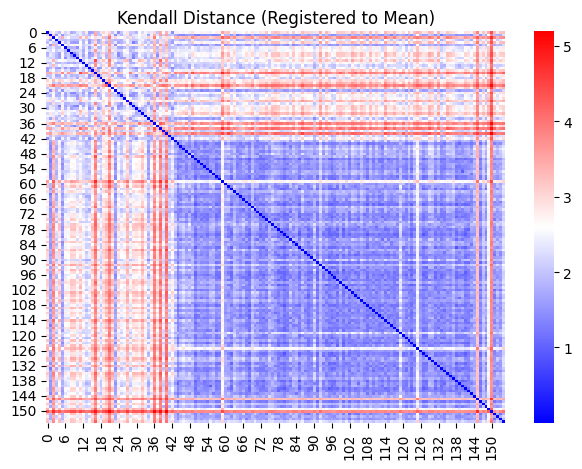

In [36]:
sns.heatmap(dist_kendall, cmap='bwr')
plt.title("Kendall Distance (Registered to Mean)")
plt.savefig('result_figures/dist_kendall.png', dpi=300, bbox_inches='tight')
plt.savefig('result_figures/dist_kendall.eps', bbox_inches='tight')
plt.tight_layout()
plt.show()

In [12]:
dist_pairwise_kendall = np.load('dist_kendall.pkl',allow_pickle=True)

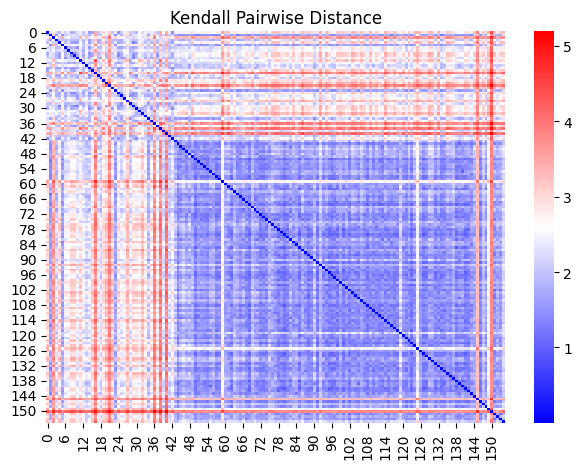

In [13]:
sns.heatmap(dist_pairwise_kendall, cmap='bwr')
plt.title("Kendall Pairwise Distance")
plt.savefig('result_figures/dist_pairwise_kendall.png', dpi=300, bbox_inches='tight')
plt.savefig('result_figures/dist_pairwise_kendall.eps', bbox_inches='tight')
plt.tight_layout()
plt.show()

In [38]:
with open('dist_pairwise_kendall.pkl','wb') as f:
    pickle.dump(dist_pairwise_kendall, f)

with open('dist_kendall.pkl','wb') as f:
    pickle.dump(dist_kendall, f)

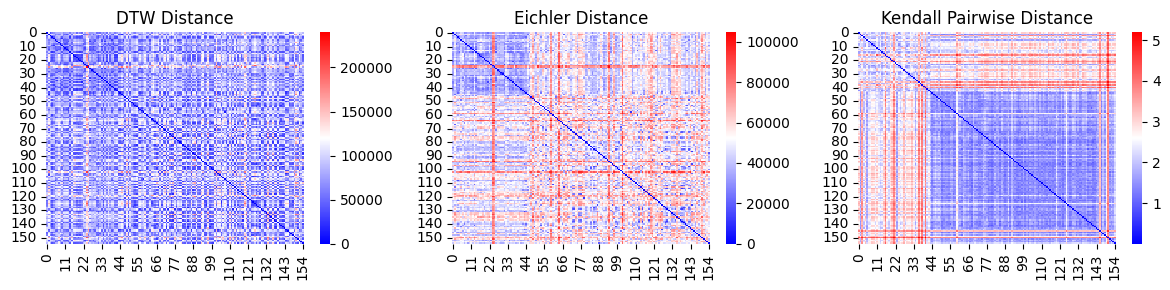

In [17]:
fig, axes = plt.subplots(1, 3, figsize=(12, 3))

sns.heatmap(dist_dtw, cmap='bwr', ax=axes[0])
axes[0].set_title("DTW Distance")

sns.heatmap(raz_dist_mat, cmap='bwr', ax=axes[1])
axes[1].set_title("Eichler Distance")

sns.heatmap(dist_pairwise_kendall, cmap='bwr', ax=axes[2])
axes[2].set_title("Kendall Pairwise Distance")

plt.tight_layout()
plt.savefig('result_figures/pairwise_dist.png', dpi=300, bbox_inches='tight')
plt.savefig('result_figures/pairwise_dist.eps', bbox_inches='tight')
plt.show()